In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import xgboost as xgb
import shap
import sys
from pathlib import Path

# This lets Python find our project modules
sys.path.insert(0, str(Path.cwd().parent))

from feature_store.engineer import build_features, get_feature_columns
from model.evaluate import compute_wmape

# Load data
DATA_RAW = Path(r"C:\Users\syeds\OneDrive\Desktop\nboracle\nb_oracle\data\raw\store-sales-time-series-forecasting")

train = pd.read_csv(DATA_RAW / "train.csv", parse_dates=["date"])
holidays = pd.read_csv(DATA_RAW / "holidays_events.csv", parse_dates=["date"])

store44 = train[train.store_nbr == 44].copy()
bev = (store44[store44.family == "BEVERAGES"]
       .sort_values("date").reset_index(drop=True))

# Build features using our shared function
bev_features = build_features(bev, holidays).dropna()
feature_columns = get_feature_columns(bev_features)

# Split by date
SPLIT_DATE = "2017-07-15"
train_data = bev_features[bev_features.index < SPLIT_DATE]
test_data = bev_features[bev_features.index >= SPLIT_DATE]

X_train = train_data[feature_columns]
y_train = train_data["sales"]
X_test = test_data[feature_columns]
y_test = test_data["sales"]

# Train model
model = xgb.XGBRegressor(
    objective="reg:tweedie", tweedie_variance_power=1.6,
    n_estimators=500, max_depth=6, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.7, min_child_weight=10,
    reg_alpha=0.1, reg_lambda=1.0, random_state=42,
    early_stopping_rounds=30)

model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)
print("✅ Model trained. Ready for SHAP.")

✅ Model trained. Ready for SHAP.


In [2]:
# calculating SHAP values
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

print(f"SHAP values calculated for {len(X_test)} test days")
print(f"Shape: {shap_values.shape}")
print(f"  → {shap_values.shape[0]} days × {shap_values.shape[1]} features")

SHAP values calculated for 32 test days
Shape: (32, 14)
  → 32 days × 14 features


In [3]:
# explaining one specific day:
highest_day_idx = y_test.values.argmax()
highest_day_date = y_test.index[highest_day_idx]
actual_sales = y_test.values[highest_day_idx]
predicted_sales = model.predict(X_test.iloc[[highest_day_idx]])[0]

print(f"Highest sales day: {highest_day_date.date()}")
print(f"Actual sales: {actual_sales:,.0f} units")
print(f"Predicted:    {predicted_sales:,.0f} units")
print(f"\nSHAP explanation (what pushed the prediction up or down):")
print("=" * 55)

day_shap = pd.Series(shap_values[highest_day_idx], index=feature_columns)
day_shap_sorted = day_shap.reindex(day_shap.abs().sort_values(ascending=False).index)

for feat_name, shap_val in day_shap_sorted.items():
    feat_value = X_test.iloc[highest_day_idx][feat_name]
    direction = "↑ UP" if shap_val > 0 else "↓ DOWN"
    print(f"  {feat_name:<25s} = {feat_value:>8.1f}  →  pushed {direction} by {abs(shap_val):>8.0f}")

Highest sales day: 2017-07-30
Actual sales: 18,340 units
Predicted:    14,576 units

SHAP explanation (what pushed the prediction up or down):
  day_of_week               =      6.0  →  pushed ↑ UP by        0
  sales_avg_7d              =  10291.6  →  pushed ↑ UP by        0
  sales_same_dow_avg_4w     =  16025.2  →  pushed ↑ UP by        0
  sales_1w_ago              =  14396.0  →  pushed ↑ UP by        0
  is_weekend                =      1.0  →  pushed ↑ UP by        0
  sales_avg_14d             =  10612.6  →  pushed ↑ UP by        0
  sales_2w_ago              =  16317.0  →  pushed ↑ UP by        0
  on_promotion              =     35.0  →  pushed ↑ UP by        0
  sales_avg_28d             =  10858.1  →  pushed ↑ UP by        0
  day_of_month              =     30.0  →  pushed ↓ DOWN by        0
  sales_trend               =   -642.0  →  pushed ↓ DOWN by        0
  is_holiday                =      0.0  →  pushed ↓ DOWN by        0
  is_payday                 =      0.0  →  push

In [4]:
# human readable alert messages:
def explain_prediction(model, explainer, features_row, feature_names, date):
    prediction = max(model.predict(features_row.values.reshape(1, -1))[0], 0)
    sv = explainer.shap_values(features_row.values.reshape(1, -1))[0]
    shap_series = pd.Series(sv, index=feature_names)
    top_3 = shap_series.abs().nlargest(3).index.tolist()

    reasons = []
    for feat in top_3:
        val = features_row[feat]
        shap_val = shap_series[feat]

        if feat == "is_weekend" and val == 1:
            reasons.append("it's a weekend (historically your busiest days)")
        elif feat == "is_weekend" and val == 0:
            reasons.append("it's a weekday (typically slower)")
        elif feat == "day_of_week":
            day_names = ["Monday","Tuesday","Wednesday","Thursday",
                        "Friday","Saturday","Sunday"]
            reasons.append(f"it's a {day_names[int(val)]}")
        elif feat == "sales_avg_7d":
            direction = "above" if shap_val > 0 else "below"
            reasons.append(f"your recent 7-day average ({val:,.0f}) is {direction} normal")
        elif feat == "sales_1w_ago":
            reasons.append(f"same day last week you sold {val:,.0f} units")
        elif feat == "sales_same_dow_avg_4w":
            reasons.append(f"this weekday has been averaging {val:,.0f} units lately")
        elif feat == "sales_trend":
            direction = "trending up" if val > 0 else "trending down"
            reasons.append(f"sales have been {direction} this week")
        elif feat == "is_holiday" and val == 1:
            reasons.append("it's a holiday")
        elif feat == "is_payday" and val == 1:
            reasons.append("it's around payday (people spend more)")
        elif feat == "on_promotion" and val == 1:
            reasons.append("this category is on promotion")
        else:
            direction = "increasing" if shap_val > 0 else "decreasing"
            reasons.append(f"{feat} is {direction} demand")

    reasons_text = ", ".join(reasons[:-1]) + f", and {reasons[-1]}" if len(reasons) > 2 else " and ".join(reasons)

    message = f"📅 Forecast for {date.strftime('%A, %B %d')}:\n"
    message += f"   Predicted demand: ~{prediction:,.0f} units\n\n"
    message += f"   Why? Because {reasons_text}."
    return message, prediction

print("=" * 60)
print("  SAMPLE STORE OWNER ALERTS — Beverages, Store 44")
print("=" * 60)

interesting_days = [
    y_test.values.argmax(),
    y_test.values.argmin(),
    5, 15, 25
]

for idx in interesting_days:
    date = y_test.index[idx]
    features_row = X_test.iloc[idx]
    actual = y_test.values[idx]
    message, pred = explain_prediction(
        model, explainer, features_row, feature_columns, date)
    print(f"\n{message}")
    print(f"   Actual sales: {actual:,.0f} units")
    print(f"   {'✅ Good prediction' if abs(pred - actual) / actual < 0.15 else '⚠️  Off by more than 15%'}")
    print("-" * 60)

  SAMPLE STORE OWNER ALERTS — Beverages, Store 44

📅 Forecast for Sunday, July 30:
   Predicted demand: ~14,576 units

   Why? Because it's a Sunday, your recent 7-day average (10,292) is above normal, and this weekday has been averaging 16,025 units lately.
   Actual sales: 18,340 units
   ⚠️  Off by more than 15%
------------------------------------------------------------

📅 Forecast for Tuesday, July 25:
   Predicted demand: ~8,232 units

   Why? Because your recent 7-day average (10,594) is above normal, it's a Tuesday, and sales_avg_14d is increasing demand.
   Actual sales: 6,862 units
   ⚠️  Off by more than 15%
------------------------------------------------------------

📅 Forecast for Thursday, July 20:
   Predicted demand: ~8,045 units

   Why? Because your recent 7-day average (11,849) is above normal, it's a Thursday, and this weekday has been averaging 7,344 units lately.
   Actual sales: 7,934 units
   ✅ Good prediction
--------------------------------------------------

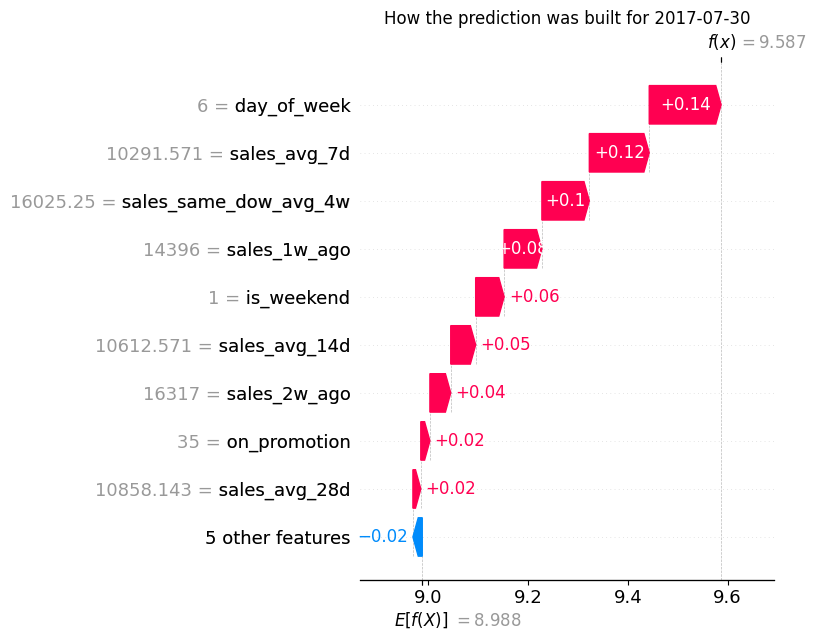

In [5]:
# waterfall chart:
idx = y_test.values.argmax()

shap.waterfall_plot(
    shap.Explanation(
        values=shap_values[idx],
        base_values=explainer.expected_value,
        data=X_test.iloc[idx].values,
        feature_names=feature_columns
    ),
    show=False
)
plt.title(f"How the prediction was built for {y_test.index[idx].date()}")
plt.tight_layout()
plt.show()